In [1]:
#-------------------- 1. Importation des librairies pour l'EDA------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
# -----------2. Chargement des données -------------------
df = pd.read_excel(r'../data/processed/app_data_sans_critiques.xlsx')
df.shape

(776, 41)

In [3]:
# ------------------3. Revérification des valeurs manquantes et doublons---------------------------
print("valeur manquante :", df.isnull().sum())
print("Nombre de lignes en double :", df.duplicated().sum())
total_missing = df.isnull().sum().sum()
total_duplicates = df.duplicated().sum()
if total_missing == 0 and total_duplicates == 0:
    print("Le fichier est bien nettoyé : aucune valeur manquante ni doublon.")
else:
    print(f"Le fichier n'est pas totalement nettoyé : {total_missing} valeurs manquantes, {total_duplicates} doublons.")

valeur manquante : Age                                 0
BMI                                 0
Sex                                 0
Height                              0
Weight                              0
Length_of_Stay                      0
Management                          0
Severity                            0
Diagnosis_Presumptive               0
Diagnosis                           0
Alvarado_Score                      0
Paedriatic_Appendicitis_Score       0
Appendix_on_US                      0
Appendix_Diameter                   0
Migratory_Pain                      0
Lower_Right_Abd_Pain                0
Contralateral_Rebound_Tenderness    0
Coughing_Pain                       0
Nausea                              0
Loss_of_Appetite                    0
Body_Temperature                    0
WBC_Count                           0
Neutrophil_Percentage               0
Neutrophilia                        0
RBC_Count                           0
Hemoglobin                     

In [4]:
#- ---------------4. Listes des variables numériques et catégorielles-----------------------------
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
print("Variables numériques :", numerical_cols)
categorical_cols = df.select_dtypes(include=['str', 'string', 'category', 'bool']).columns.tolist()
print("Variables catégorielles :", categorical_cols)

Variables numériques : ['Age', 'BMI', 'Height', 'Weight', 'Length_of_Stay', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'CRP', 'US_Number', 'CRP_log']
Variables catégorielles : ['Sex', 'Management', 'Severity', 'Diagnosis_Presumptive', 'Diagnosis', 'Appendix_on_US', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Neutrophilia', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed', 'Free_Fluids']


In [5]:
#------ -------------------5. Statistiques descriptives-----------------------------------------------
print(df.describe())
print(df.dtypes)

              Age         BMI      Height      Weight  Length_of_Stay  \
count  776.000000  776.000000  776.000000  776.000000      776.000000   
mean    11.345274   18.773462  148.071456   43.198273        4.052835   
std      3.526092    4.000675   19.443962   17.378752        1.779755   
min      0.000000    7.961926   53.000000    3.960000        1.000000   
25%      9.228131   15.797500  137.875000   29.875000        3.000000   
50%     11.442847   18.062284  149.650000   41.400000        3.000000   
75%     14.040383   21.021216  162.075000   54.000000        5.000000   
max     18.360000   28.856790  192.000000  103.000000        8.000000   

       Alvarado_Score  Paedriatic_Appendicitis_Score  Appendix_Diameter  \
count      776.000000                     776.000000         776.000000   
mean         5.922680                       5.238402           7.517526   
std          2.081984                       1.896311           1.250632   
min          0.000000                     

Diagnosis
appendicitis       461
no appendicitis    315
Name: count, dtype: int64

Proportions (%):
Diagnosis
appendicitis       59.41
no appendicitis    40.59
Name: proportion, dtype: float64


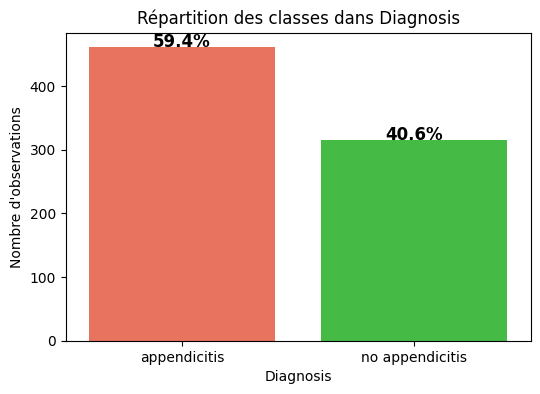

In [6]:
# -----------6. Vérification des déséquilibres des classes (exemple : Diagnosis)-----------------
target_col = 'Diagnosis'
class_counts = df[target_col].value_counts()
class_percent = df[target_col].value_counts(normalize=True) * 100
print(class_counts)
print("\nProportions (%):")
print(class_percent.round(2))

palette = {'appendicitis': 'tomato', 'no appendicitis': 'limegreen'}
#Visualisation
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, hue=target_col, palette=palette, legend=False)
for i, (count, percent) in enumerate(zip(class_counts, class_percent)):
    plt.text(i, count + 0.5, f'{percent:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.title(f"Répartition des classes dans {target_col}")
plt.xlabel(target_col)
plt.ylabel("Nombre d'observations")
plt.show()

Corrélation avec la cible :
US_Number                        0.240728
BMI                              0.135533
Weight                           0.100003
Age                              0.086372
Height                           0.062101
Hemoglobin                       0.018404
Thrombocyte_Count               -0.000441
RBC_Count                       -0.002902
RDW                             -0.029700
Body_Temperature                -0.149984
CRP                             -0.278897
Neutrophil_Percentage           -0.328858
Paedriatic_Appendicitis_Score   -0.338008
WBC_Count                       -0.362745
CRP_log                         -0.385060
Alvarado_Score                  -0.403147
Length_of_Stay                  -0.453901
Appendix_Diameter               -0.470153
Name: Diagnosis, dtype: float64


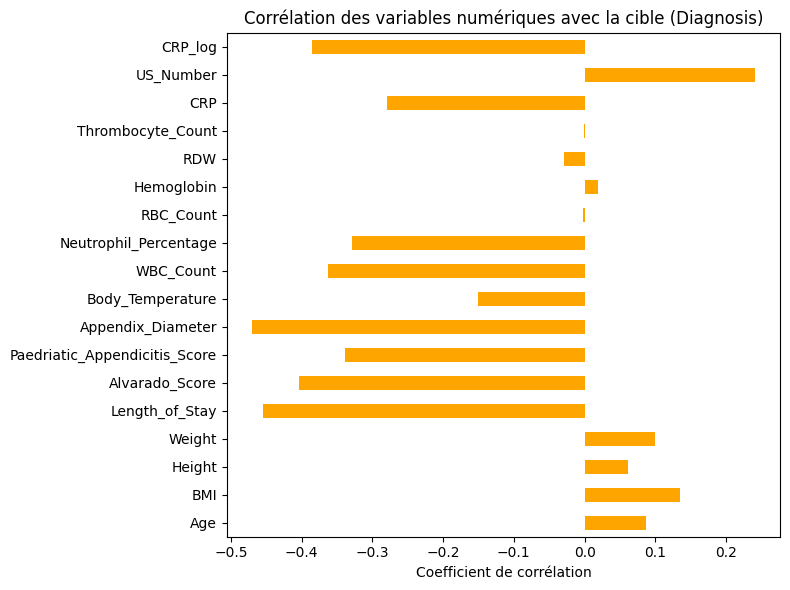

In [7]:
# 7. Identification des features les plus corrélées à la cible
# On encode Diagnosis si nécessaire, puis on recalcule numerical_cols
# APRÈS l'encodage pour que la colonne soit bien reconnue comme numérique.
if df['Diagnosis'].dtype == object or str(df['Diagnosis'].dtype) in ('object', 'string', 'str'):
    df['Diagnosis'] = LabelEncoder().fit_transform(df['Diagnosis'])

# Recalcul APRÈS encodage
numerical_cols = df.select_dtypes(include='number').columns.tolist()
correlation_matrix = df[numerical_cols].corr()

if target_col in correlation_matrix.columns:
    corr_target = correlation_matrix[target_col].drop(target_col)
    print("Corrélation avec la cible :")
    print(corr_target.sort_values(ascending=False))
    plt.figure(figsize=(8, 6))
    corr_target.plot(kind='barh', color='orange')
    plt.title("Corrélation des variables numériques avec la cible (Diagnosis)")
    plt.xlabel("Coefficient de corrélation")
    plt.tight_layout()
    plt.show()
else:
    print("La colonne cible n'est pas présente dans la matrice de corrélation.")


                                    Age       BMI    Height    Weight  \
Age                            1.000000  0.484780  0.849352  0.763758   
BMI                            0.484780  1.000000  0.484262  0.853933   
Height                         0.849352  0.484262  1.000000  0.819444   
Weight                         0.763758  0.853933  0.819444  1.000000   
Length_of_Stay                -0.145438 -0.081363 -0.142455 -0.105695   
Diagnosis                      0.086372  0.135533  0.062101  0.100003   
Alvarado_Score                -0.171976 -0.129503 -0.125617 -0.141303   
Paedriatic_Appendicitis_Score -0.122775 -0.112812 -0.101792 -0.119737   
Appendix_Diameter             -0.017859  0.013541  0.002482  0.026669   
Body_Temperature              -0.293591 -0.171773 -0.240733 -0.227514   
WBC_Count                     -0.249171 -0.130782 -0.201012 -0.181068   
Neutrophil_Percentage         -0.161119 -0.168393 -0.115217 -0.163553   
RBC_Count                      0.090034  0.119574  

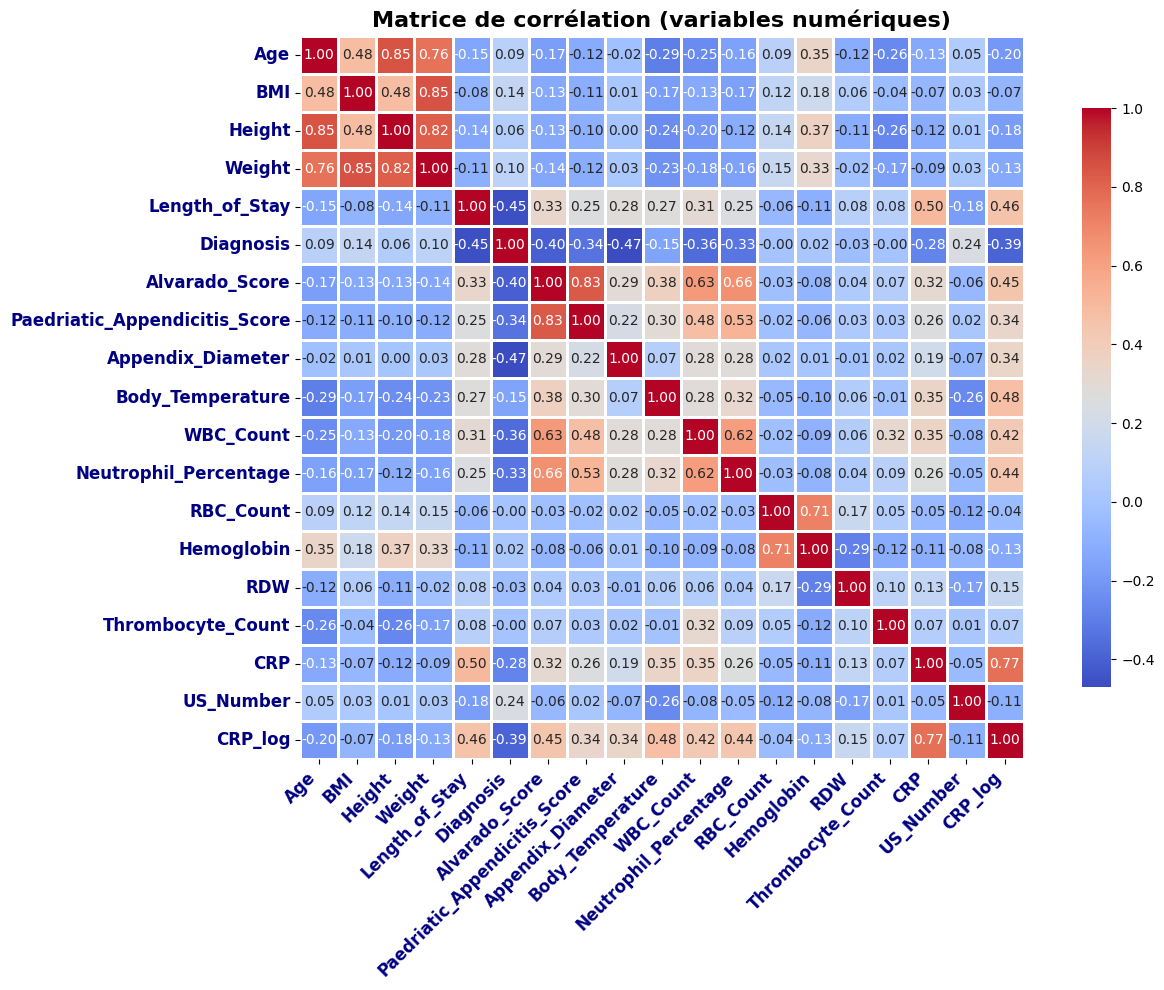

In [8]:
# -----------8.Matrice de corrélation (variables numériques uniquement)--------------------------
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
correlation = df[numerical_cols].corr()
print(correlation)
plt.figure(figsize=(max(14, len(numerical_cols)*0.7), max(10, len(numerical_cols)*0.5)))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    annot_kws={"size": 10},
    linewidths=1,
    linecolor='white',
    cbar_kws={"shrink": 0.8},
    square=True, )
plt.title("Matrice de corrélation (variables numériques)", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold', color='navy')
plt.yticks(rotation=0, fontsize=12, fontweight='bold', color='navy')
plt.tight_layout()
plt.show()

                                                    Sex_male  \
Sex_male                                            1.000000   
Management_primary surgical                         0.089884   
Management_secondary surgical                      -0.041545   
Management_simultaneous appendectomy               -0.037145   
Severity_uncomplicated                             -0.003891   
Diagnosis_Presumptive_Appendizitis, Lymphadenit...  0.034737   
Diagnosis_Presumptive_Appendizitis/ Lymphadenit...  0.034737   
Diagnosis_Presumptive_Bridenileus                  -0.037145   
Diagnosis_Presumptive_Gastroenteritis               0.060244   
Diagnosis_Presumptive_Ovarialtorsion               -0.037145   
Diagnosis_Presumptive_Sepsis mit Begleitappendi... -0.037145   
Diagnosis_Presumptive_Torsion der Adnexe           -0.037145   
Diagnosis_Presumptive_abdominelle Adhäsionen, c... -0.037145   
Diagnosis_Presumptive_appendicitis                  0.047759   
Diagnosis_Presumptive_chronische Appendi

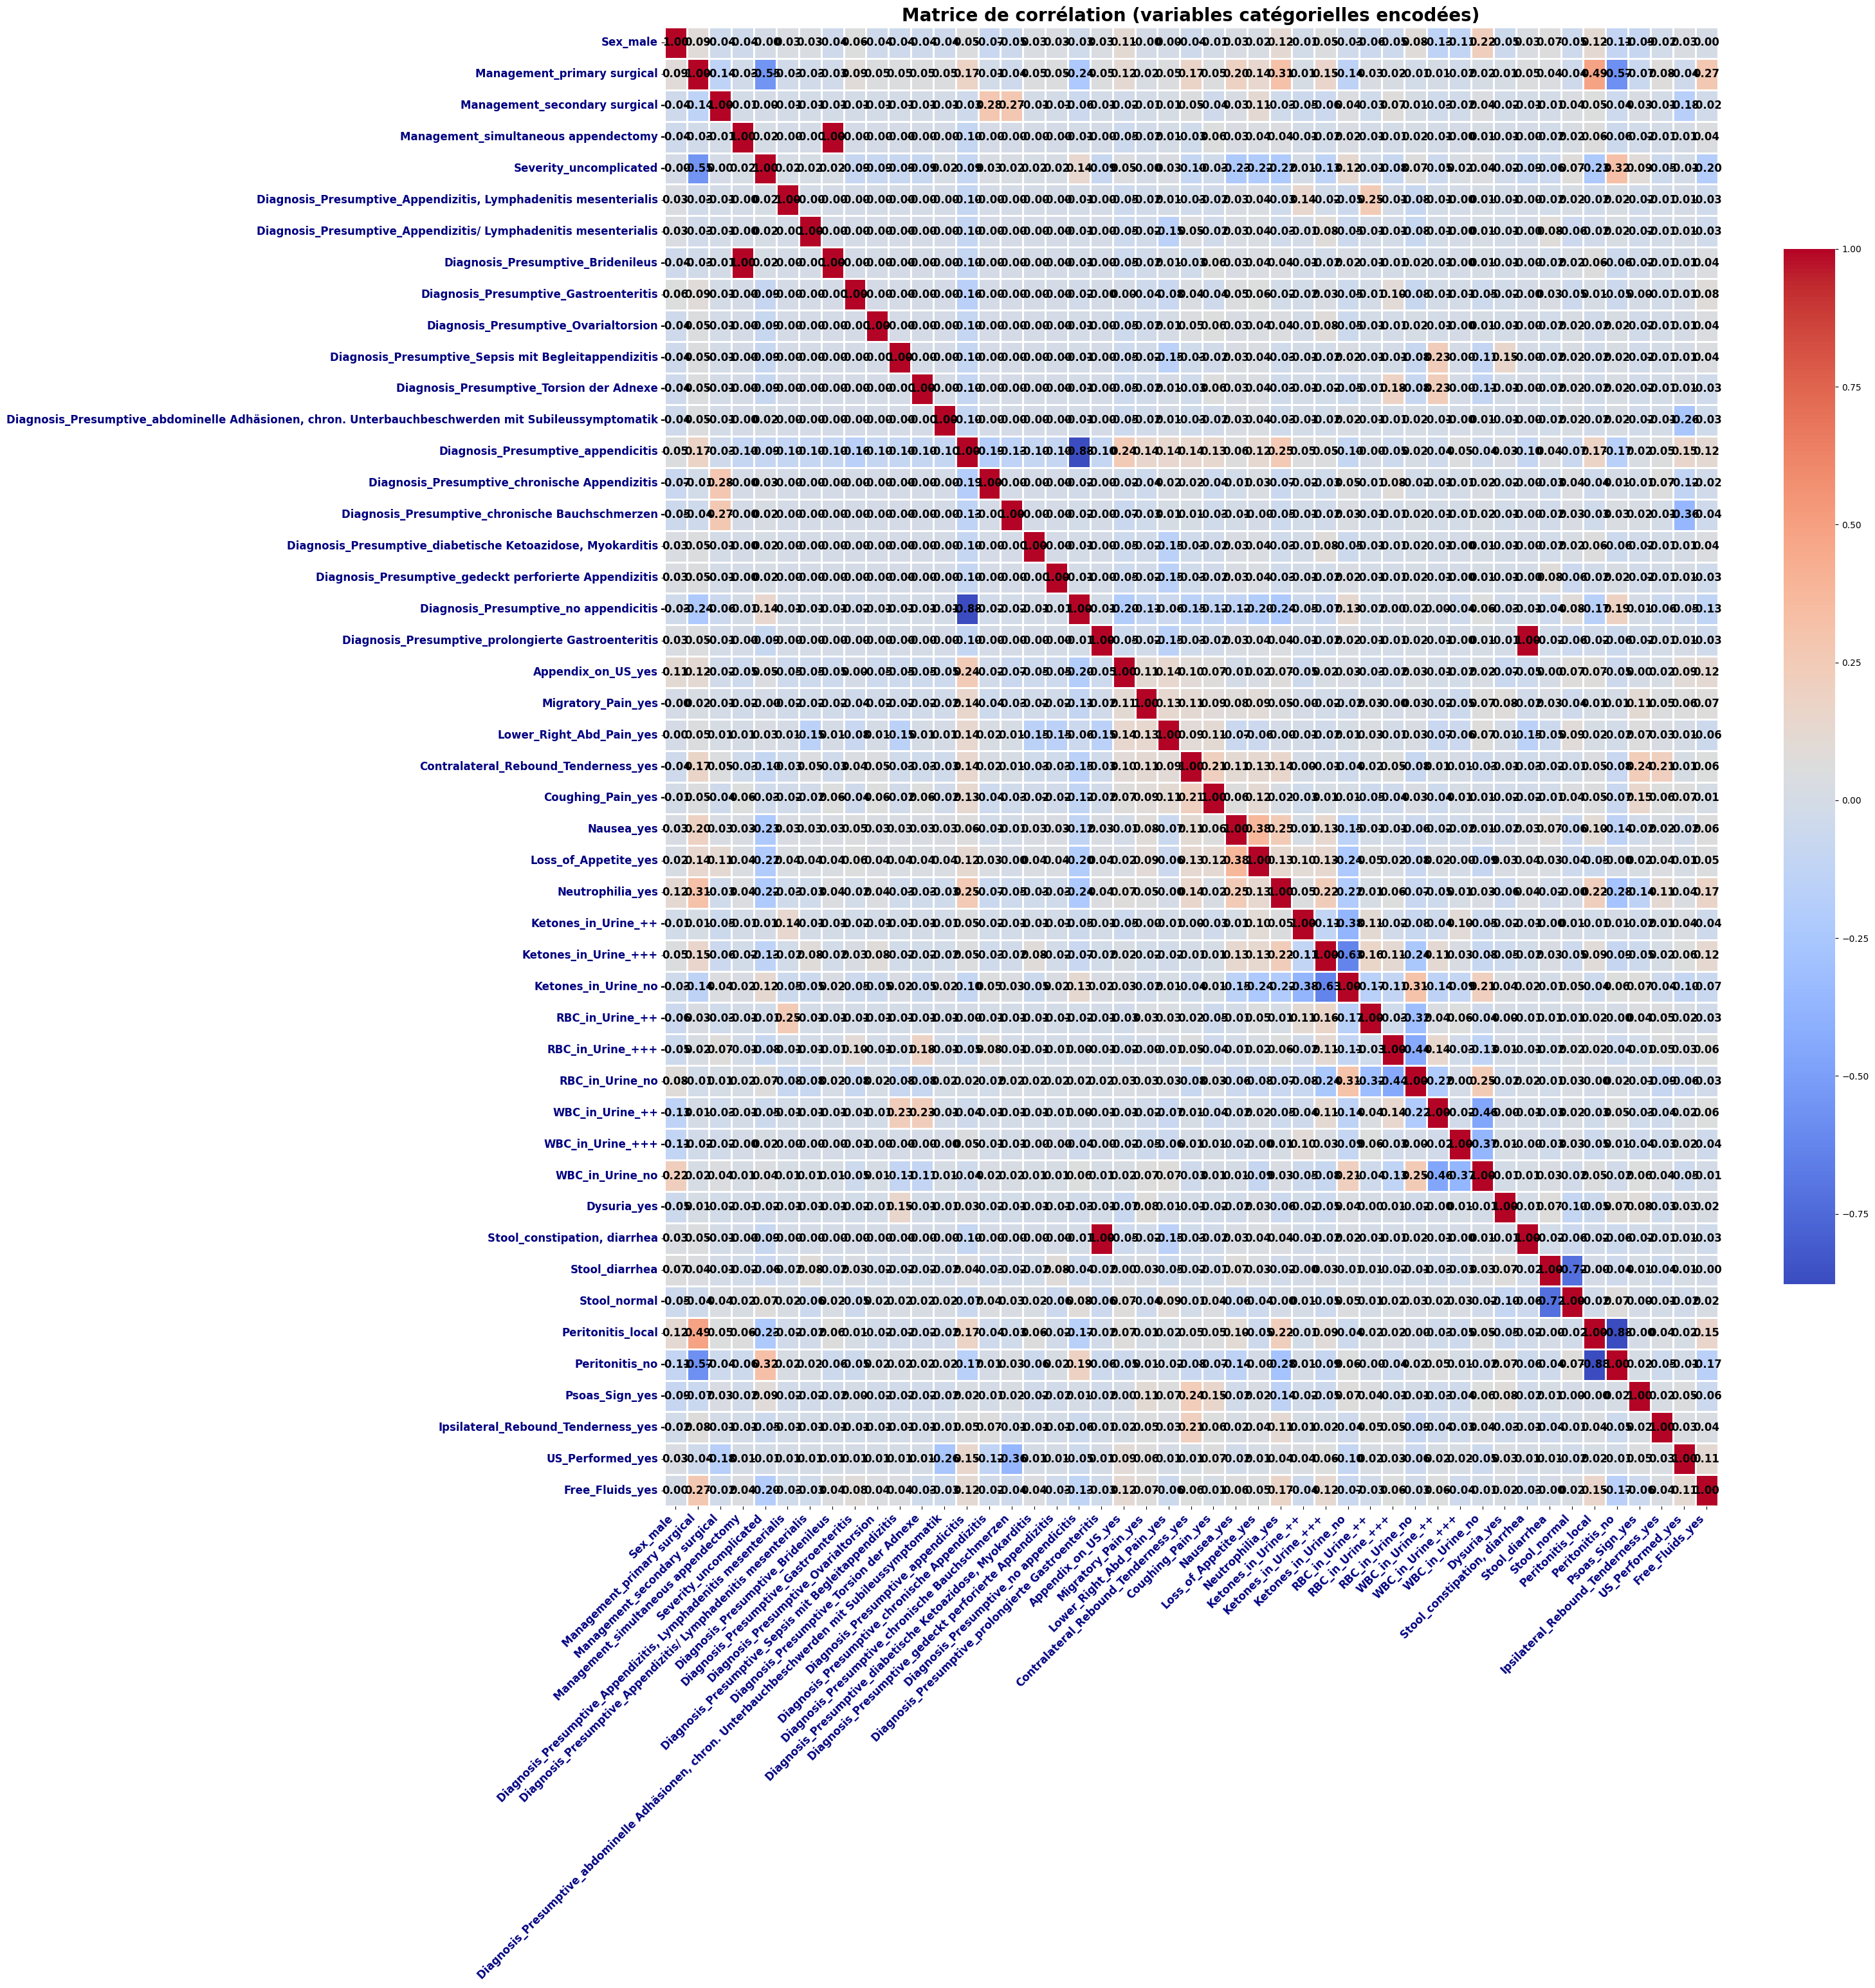

In [9]:
# ----------9.Matrice de corrélation (variables catégorielles encodées uniquement)---------------
categorical_cols = df.select_dtypes(include=['str', 'string', 'category', 'bool']).columns.tolist()
if categorical_cols:
    df_cat = pd.get_dummies(df[categorical_cols], drop_first=True)
    if not df_cat.empty:
        correlation_cat = df_cat.corr()
        print(correlation_cat)
        plt.figure(figsize=(max(14, len(df_cat.columns)//1.5), max(12, len(df_cat.columns)//1.5)))
        ax = sns.heatmap(
            correlation_cat,
            annot=True,  # Affiche les valeurs sur la heatmap
            fmt=".2f",  # Format des valeurs
            cmap='coolwarm',
            linewidths=1,
            linecolor='white',
            cbar_kws={"shrink": 0.7},
            annot_kws={"size": 12, "color": "black", "weight": "bold"}  # Style des annotations
        )
        plt.title("Matrice de corrélation (variables catégorielles encodées)", fontsize=20, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold', color='navy')
        plt.yticks(rotation=0, fontsize=12, fontweight='bold', color='navy')
        plt.tight_layout()
        plt.show()
    else:
        print("Aucune variable catégorielle encodable.")
else:
    print("Aucune variable catégorielle dans le jeu de données.")

In [10]:
# 10.Couples de variables fortement corrélées (|corr| >= 0.7) sur toutes les variables (numériques + catégorielles encodées)
seuil = 0.7
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['str', 'string', 'category', 'bool']).columns.tolist()
df_cat = pd.get_dummies(df[categorical_cols], drop_first=True) if categorical_cols else pd.DataFrame()
if not df_cat.empty:
    df_total = pd.concat([df[numerical_cols], df_cat], axis=1)
else:
    df_total = df[numerical_cols]
correlation_matrix_total = df_total.corr().abs()
mask = np.triu(np.ones(correlation_matrix_total.shape), k=1).astype(bool)
corr_pairs = correlation_matrix_total.where(mask)
fortement_corr = corr_pairs.stack().sort_values(ascending=False)
print("Couples de variables fortement corrélées (|corr| >= 0.7) :")
print(fortement_corr[fortement_corr >= seuil])
liste_couples = [(var1, var2, corr) for (var1, var2), corr in fortement_corr.items() if corr >= seuil]
print("Liste des couples de variables fortement corrélées :")
print(liste_couples)

Couples de variables fortement corrélées (|corr| >= 0.7) :
Management_simultaneous appendectomy                Diagnosis_Presumptive_Bridenileus        1.000000
Diagnosis_Presumptive_prolongierte Gastroenteritis  Stool_constipation, diarrhea             1.000000
Diagnosis_Presumptive_appendicitis                  Diagnosis_Presumptive_no appendicitis    0.878124
Peritonitis_local                                   Peritonitis_no                           0.878010
BMI                                                 Weight                                   0.853933
Age                                                 Height                                   0.849352
Alvarado_Score                                      Paedriatic_Appendicitis_Score            0.831861
Height                                              Weight                                   0.819444
CRP                                                 CRP_log                                  0.765907
Age                    

In [11]:
#VERSION FINALE DE LA MATRICE 
print("La matrice finale est de taille")
print(df.shape) 
print("Les colonnes restantes")    
print(df.columns.tolist()) 
df.head(5) 

La matrice finale est de taille
(776, 41)
Les colonnes restantes
['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Length_of_Stay', 'Management', 'Severity', 'Diagnosis_Presumptive', 'Diagnosis', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_on_US', 'Appendix_Diameter', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Neutrophilia', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed', 'US_Number', 'Free_Fluids', 'CRP_log']


,Age,BMI,Sex,Height,Weight,Length_of_Stay,Management,Severity,Diagnosis_Presumptive,Diagnosis,...,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,US_Performed,US_Number,Free_Fluids,CRP_log
0,12.68,16.90000,female,148.0,37.0,3,conservative,uncomplicated,appendicitis,0,...,0.0,no,normal,no,yes,no,yes,882.0,no,0.000000
1,14.10,28.85679,male,147.0,69.5,2,conservative,uncomplicated,appendicitis,1,...,3.0,yes,normal,no,yes,no,yes,883.0,no,1.386294
2,14.14,23.30000,female,163.0,62.0,4,conservative,uncomplicated,appendicitis,1,...,3.0,no,constipation,no,yes,no,yes,884.0,no,1.386294
3,16.37,20.60000,female,165.0,56.0,3,conservative,uncomplicated,appendicitis,1,...,0.0,yes,normal,no,yes,no,yes,886.0,no,0.000000
4,11.08,16.90000,female,163.0,45.0,3,conservative,uncomplicated,appendicitis,0,...,0.0,no,constipation,no,yes,no,yes,887.0,no,0.000000


### Par suite
On supprime les variables correlées non pertinentes
Et on refait l'etude de correlation

### ----------  Suppression des colonnes fortement corrélées et non pertinentes-------------------


In [12]:
# Suppression des colonnes fortement corrélées et non pertinentes
df_cleaned = df.copy()
colonnes_a_supprimer = list(set([
    'Peritonitis', 'Weight', 'Height', 'Alvarado_Score', 'Neutrophilia', 'Stool', 'RBC_Count', 'Paedriatic_Appendicitis_Score',
    'Management', 'Severity', 'Length_of_Stay', 'Diagnosis_Presumptive', 'US_Number', 'CRP_log'
]))
df_cleaned = df_cleaned.drop(columns=[col for col in colonnes_a_supprimer if col in df_cleaned.columns])
print(f"Nouvelles dimensions : {df_cleaned.shape}")
print(f"Colonnes restantes : {df_cleaned.columns.tolist()}")

Nouvelles dimensions : (776, 27)
Colonnes restantes : ['Age', 'BMI', 'Sex', 'Diagnosis', 'Appendix_on_US', 'Appendix_Diameter', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed', 'Free_Fluids']


### ---------- Verification par une seconde etude de correlation-------------------


Matrice de corrélation - Version finale:
                            Age       BMI  Diagnosis  Appendix_Diameter  \
Age                    1.000000  0.484780   0.086372          -0.017859   
BMI                    0.484780  1.000000   0.135533           0.013541   
Diagnosis              0.086372  0.135533   1.000000          -0.470153   
Appendix_Diameter     -0.017859  0.013541  -0.470153           1.000000   
Body_Temperature      -0.293591 -0.171773  -0.149984           0.074817   
WBC_Count             -0.249171 -0.130782  -0.362745           0.283515   
Neutrophil_Percentage -0.161119 -0.168393  -0.328858           0.278952   
Hemoglobin             0.346576  0.179594   0.018404           0.010348   
RDW                   -0.115251  0.055643  -0.029700          -0.011698   
Thrombocyte_Count     -0.255215 -0.042370  -0.000441           0.021364   
CRP                   -0.129982 -0.065820  -0.278897           0.191228   

                       Body_Temperature  WBC_Count  Neutro

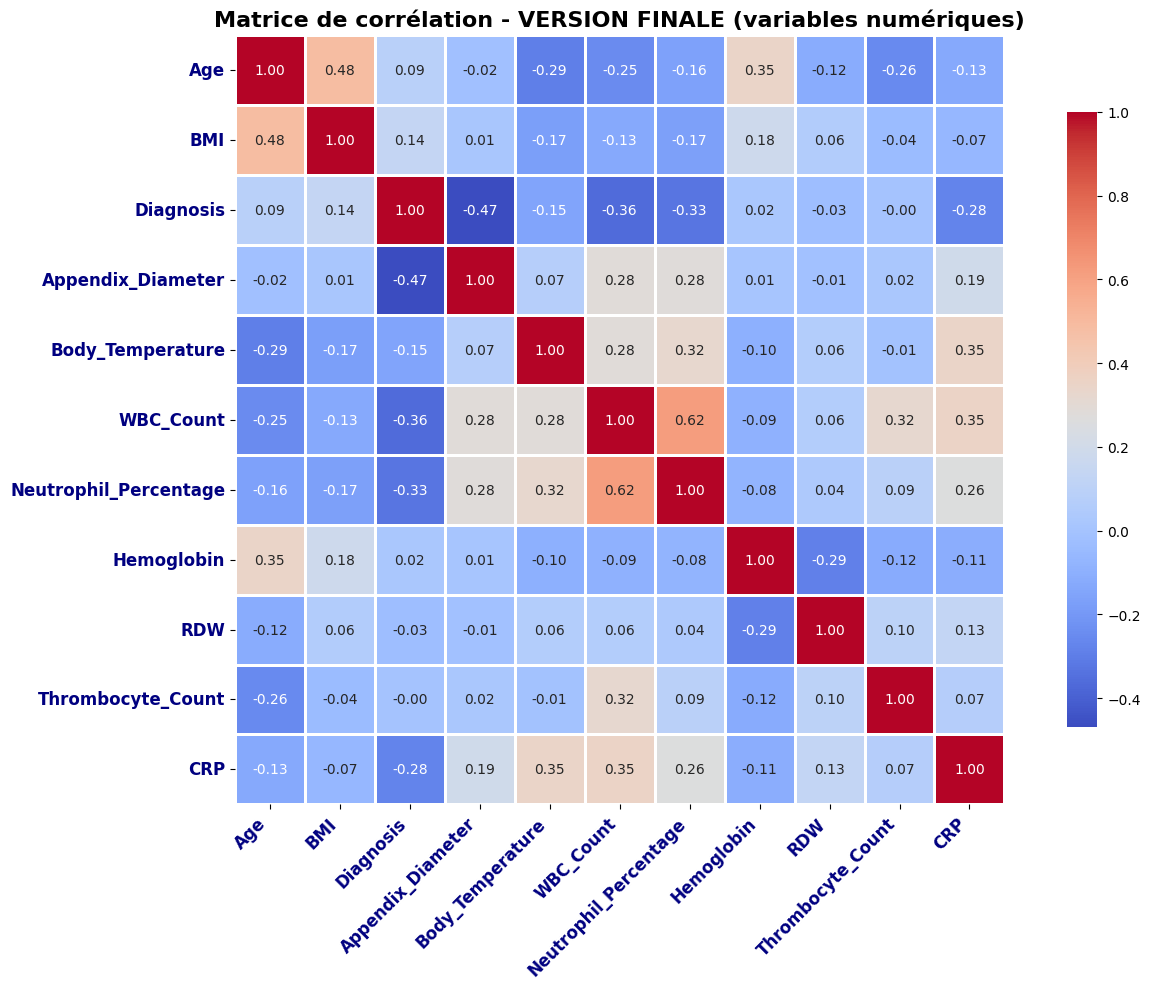

In [13]:
# Matrice de corrélation (variables numériques uniquement) - VERSION FINALE
numerical_cols_cleaned = df_cleaned.select_dtypes(include=['number']).columns.tolist()
correlation_cleaned = df_cleaned[numerical_cols_cleaned].corr()
print("Matrice de corrélation - Version finale:")
print(correlation_cleaned)
plt.figure(figsize=(max(14, len(numerical_cols_cleaned)*0.7), max(10, len(numerical_cols_cleaned)*0.5)))
sns.heatmap(
    correlation_cleaned,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    annot_kws={"size": 10},
    linewidths=1,
    linecolor='white',
    cbar_kws={"shrink": 0.8},
    square=True)
plt.title("Matrice de corrélation - VERSION FINALE (variables numériques)", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold', color='navy')
plt.yticks(rotation=0, fontsize=12, fontweight='bold', color='navy')
plt.tight_layout()
plt.show()

Matrice de corrélation (variables catégorielles encodées) - VERSION FINALE:
                                      Sex_male  Appendix_on_US_yes  \
Sex_male                              1.000000            0.111103   
Appendix_on_US_yes                    0.111103            1.000000   
Migratory_Pain_yes                   -0.000202            0.109012   
Lower_Right_Abd_Pain_yes              0.002154            0.140399   
Contralateral_Rebound_Tenderness_yes -0.039661            0.095037   
Coughing_Pain_yes                    -0.009479            0.068579   
Nausea_yes                            0.025388           -0.009960   
Loss_of_Appetite_yes                  0.022352            0.018940   
Ketones_in_Urine_++                  -0.014005           -0.053576   
Ketones_in_Urine_+++                  0.052530            0.023024   
Ketones_in_Urine_no                  -0.032325            0.029377   
RBC_in_Urine_++                      -0.059305           -0.026452   
RBC_in_Urine_+

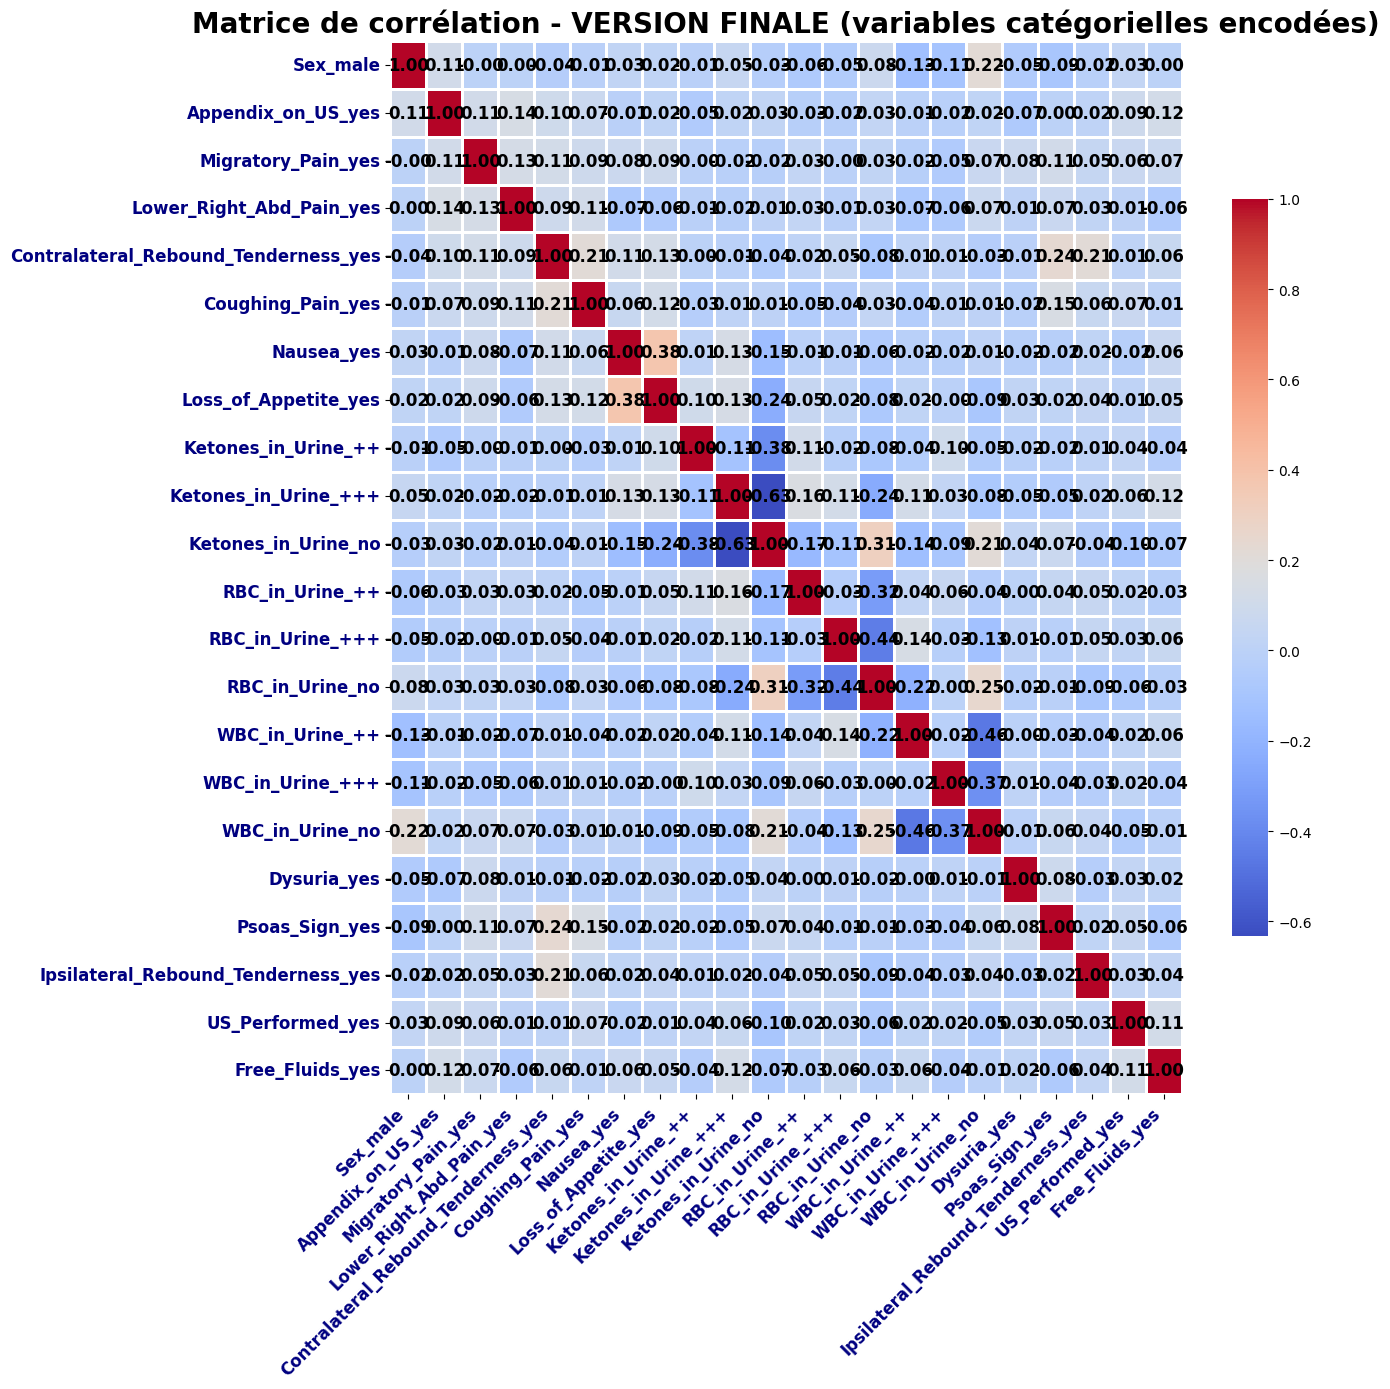

In [14]:
# Matrice de corrélation (variables catégorielles encodées) - VERSION FINALE
categorical_cols_cleaned = df_cleaned.select_dtypes(include=['str', 'string', 'category', 'bool']).columns.tolist()
if categorical_cols_cleaned:
    df_cat_cleaned = pd.get_dummies(df_cleaned[categorical_cols_cleaned], drop_first=True)
    if not df_cat_cleaned.empty:
        correlation_cat_cleaned = df_cat_cleaned.corr()
        print("Matrice de corrélation (variables catégorielles encodées) - VERSION FINALE:")
        print(correlation_cat_cleaned)
        plt.figure(figsize=(max(14, len(df_cat_cleaned.columns)//1.5), max(12, len(df_cat_cleaned.columns)//1.5)))
        sns.heatmap(
            correlation_cat_cleaned,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            linewidths=1,
            linecolor='white',
            cbar_kws={"shrink": 0.7},
            annot_kws={"size": 12, "color": "black", "weight": "bold"}
        )
        plt.title("Matrice de corrélation - VERSION FINALE (variables catégorielles encodées)", fontsize=20, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold', color='navy')
        plt.yticks(rotation=0, fontsize=12, fontweight='bold', color='navy')
        plt.tight_layout()
        plt.show()
    else:
        print("Aucune variable catégorielle encodable.")
else:
    print("Aucune variable catégorielle dans le jeu de données nettoyé.")

In [18]:
# Couples de variables fortement corrélées - VERSION FINALE
seuil_final = 0.7
numerical_cols_final = df_cleaned.select_dtypes(include=['number']).columns.tolist()
categorical_cols_final = df_cleaned.select_dtypes(include=['str', 'string', 'category', 'bool']).columns.tolist()
df_cat_final = pd.get_dummies(df_cleaned[categorical_cols_final], drop_first=True) if categorical_cols_final else pd.DataFrame()
if not df_cat_final.empty:
    df_total_final = pd.concat([df_cleaned[numerical_cols_final], df_cat_final], axis=1)
else:
    df_total_final = df_cleaned[numerical_cols_final]
correlation_matrix_total_final = df_total_final.corr().abs()
mask_final = np.triu(np.ones(correlation_matrix_total_final.shape), k=1).astype(bool)
corr_pairs_final = correlation_matrix_total_final.where(mask_final)
fortement_corr_final = corr_pairs_final.stack().sort_values(ascending=False)

print("\n" + "="*70)
print(f"ANALYSE DES COUPLES FORTEMENT CORRÉLÉS (|corr| >= {seuil_final})")
print("="*70)

liste_couples_final = [(var1, var2, corr) for (var1, var2), corr in fortement_corr_final.items() if corr >= seuil_final]

if len(liste_couples_final) == 0:
    print("✓ EXCELLENT ! Aucun couple de variables fortement corrélées détecté.")
    print("  Cela signifie que le nettoyage a bien fonctionné !")
    print("  Les variables redondantes ont été supprimées avec succès.")
else:
    print(f"\nCouples détectés : {len(liste_couples_final)}\n")
    for i, (var1, var2, corr) in enumerate(liste_couples_final, 1):
        print(f"  {i}. {var1:30} <--> {var2:30} | Corrélation: {corr:.4f}")

print("="*70)


ANALYSE DES COUPLES FORTEMENT CORRÉLÉS (|corr| >= 0.7)
✓ EXCELLENT ! Aucun couple de variables fortement corrélées détecté.
  Cela signifie que le nettoyage a bien fonctionné !
  Les variables redondantes ont été supprimées avec succès.


In [19]:
# Résumé FINAL du dataset nettoyé
print("=" * 60)
print("RÉSUMÉ FINAL DU DATASET")
print("=" * 60)
print(f"Dimensions finales : {df_cleaned.shape}")
print(f"Nombre de variables supprimées : {df.shape[1] - df_cleaned.shape[1]}")
print(f"\nColonnes du dataset final :")
for col in df_cleaned.columns.tolist():
    print(f"  - {col}")
print(f"\nTypes de données :")
print(df_cleaned.dtypes)
print(f"\n✓ Dataset prêt pour la modélisation!")

RÉSUMÉ FINAL DU DATASET
Dimensions finales : (776, 27)
Nombre de variables supprimées : 14

Colonnes du dataset final :
  - Age
  - BMI
  - Sex
  - Diagnosis
  - Appendix_on_US
  - Appendix_Diameter
  - Migratory_Pain
  - Lower_Right_Abd_Pain
  - Contralateral_Rebound_Tenderness
  - Coughing_Pain
  - Nausea
  - Loss_of_Appetite
  - Body_Temperature
  - WBC_Count
  - Neutrophil_Percentage
  - Hemoglobin
  - RDW
  - Thrombocyte_Count
  - Ketones_in_Urine
  - RBC_in_Urine
  - WBC_in_Urine
  - CRP
  - Dysuria
  - Psoas_Sign
  - Ipsilateral_Rebound_Tenderness
  - US_Performed
  - Free_Fluids

Types de données :
Age                                 float64
BMI                                 float64
Sex                                     str
Diagnosis                             int64
Appendix_on_US                          str
Appendix_Diameter                   float64
Migratory_Pain                          str
Lower_Right_Abd_Pain                    str
Contralateral_Rebound_Tenderness  

In [20]:
# Export du dataset final nettoyé
import os
os.makedirs("../data/processed", exist_ok=True)
chemin_final = "../data/processed/data_finale.xlsx"
df_cleaned.to_excel(chemin_final, index=False)
print(f"✓ Dataset final exporté : {chemin_final}")
print(f"  Dimensions : {df_cleaned.shape[0]} lignes × {df_cleaned.shape[1]} colonnes")


✓ Dataset final exporté : ../data/processed/data_finale.xlsx
  Dimensions : 776 lignes × 27 colonnes
